# Evaluasi Sistem Rekomendasi Offline - Baseline (Pre-trained ImageNet)

Notebook ini melakukan simulasi evaluasi sistem rekomendasi offline (*intra-category recommendation*) menggunakan **master_dataset_gallery.csv** (3.981 item representatif, khusus label gallery).

- **Dataset**: `master_dataset_gallery.csv`
- **Fitur**: Feature vector baseline (ImageNet) dari `features/exp1_baseline/`
- **Model**: ResNet50, VGG19, InceptionV3, MobileNetV3
- **Metrik**: Precision@K, Recall@K, F1@K, NDCG@K, Intra-List Diversity (K = 5, 10, 20)

In [1]:
# ─────────────────────────────────────────────
# CELL 1: Imports & Setup Path
# ─────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

BASE_DIR = r'd:\Antigravity\Visual Based Rekomender Sistem'
DATA_DIR = os.path.join(BASE_DIR, 'skripsi', 'persiapan_skripsi', 'data preperation', 'dataset_output')
FEAT_DIR = os.path.join(BASE_DIR, 'features', 'exp1_baseline')
EVAL_DIR = os.path.join(BASE_DIR, 'skripsi', 'persiapan_skripsi', 'baseline', 'hasil_evaluasi')
os.makedirs(EVAL_DIR, exist_ok=True)

MODEL_NAMES = ['resnet50', 'vgg19', 'inceptionv3', 'mobilenetv3']
K_VALUES = [5, 10, 20]
N_USERS = 100
N_LIKED = 3

print('Config loaded successfully.')

Config loaded successfully.


c:\Users\Ghani\miniconda3\envs\fashion-rec\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ─────────────────────────────────────────────
# CELL 2: Load Master Dataset Gallery & Full Dataset Mapping
# ─────────────────────────────────────────────
MASTER_GALLERY_CSV = os.path.join(DATA_DIR, 'master_dataset_gallery.csv')
FULL_CSV = os.path.join(DATA_DIR, 'full_dataset.csv')

df_master_gallery = pd.read_csv(MASTER_GALLERY_CSV)
df_full = pd.read_csv(FULL_CSV)

# Filter full dataset untuk split gallery saja
df_gallery_full = df_full[df_full['split'] == 'gallery'].reset_index(drop=True)

print(f'Total item master_dataset_gallery : {len(df_master_gallery):,}')
print(f'Jumlah kategori                   : {df_master_gallery["category"].nunique()}')
print(f'Total gambar gallery full         : {len(df_gallery_full):,}')

Total item master_dataset_gallery : 3,981
Jumlah kategori                   : 16
Total gambar gallery full         : 12,612


In [3]:
# ─────────────────────────────────────────────
# CELL 3: Metrik Evaluasi Recommendation System
# ─────────────────────────────────────────────
def precision_at_k(recommended_ids, relevant_ids, k):
    top_k = recommended_ids[:k]
    hits = len(set(top_k) & set(relevant_ids))
    return hits / k

def recall_at_k(recommended_ids, relevant_ids, k):
    if len(relevant_ids) == 0:
        return 0.0
    top_k = recommended_ids[:k]
    hits = len(set(top_k) & set(relevant_ids))
    return hits / len(relevant_ids)

def f1_at_k(recommended_ids, relevant_ids, k):
    p = precision_at_k(recommended_ids, relevant_ids, k)
    r = recall_at_k(recommended_ids, relevant_ids, k)
    return (2 * p * r / (p + r)) if (p + r) > 0 else 0.0

def dcg_at_k(recommended_ids, relevant_ids, k):
    top_k = recommended_ids[:k]
    return sum(1.0 / np.log2(i + 2) for i, item in enumerate(top_k) if item in relevant_ids)

def ndcg_at_k(recommended_ids, relevant_ids, k):
    actual_dcg = dcg_at_k(recommended_ids, relevant_ids, k)
    ideal_dcg = dcg_at_k(list(relevant_ids)[:k], relevant_ids, k)
    return (actual_dcg / ideal_dcg) if ideal_dcg > 0 else 0.0

def intra_list_diversity(recommended_ids, feature_matrix, item_id_to_idx):
    indices = [item_id_to_idx[i] for i in recommended_ids if i in item_id_to_idx]
    if len(indices) < 2:
        return 0.0
    vecs = feature_matrix[indices]
    sim_matrix = vecs @ vecs.T
    n = len(indices)
    pairs = [(i, j) for i in range(n) for j in range(i + 1, n)]
    diversity = sum(1.0 - sim_matrix[i, j] for i, j in pairs)
    return diversity / len(pairs)

print('Fungsi metrik evaluasi siap.')

Fungsi metrik evaluasi siap.


In [4]:
# ─────────────────────────────────────────────
# CELL 4: Recommendation Engine Helpers
# ─────────────────────────────────────────────
def build_user_profile(liked_indices, feature_matrix):
    vecs = feature_matrix[liked_indices]
    profile = np.mean(vecs, axis=0)
    norm = np.linalg.norm(profile)
    return profile / norm if norm > 0 else profile

def get_recommendations(user_profile, feature_matrix, exclude_indices, top_n=20):
    scores = feature_matrix @ user_profile
    scores[exclude_indices] = -1.0
    ranked_idx = np.argsort(scores)[::-1]
    ranked_idx = [i for i in ranked_idx if i not in set(exclude_indices)]
    return [(i, float(scores[i])) for i in ranked_idx[:top_n]]

print('Helper rekomendasi siap.')

Helper rekomendasi siap.


In [5]:
# ─────────────────────────────────────────────
# CELL 5: Simulasi Evaluasi Rekomendasi
# ─────────────────────────────────────────────
def simulate_evaluation(feature_matrix, df_sub, n_users=100, n_liked=3, k_values=[5, 10, 20]):
    item_id_to_idx = {row['item_id']: idx for idx, row in df_sub.iterrows()}
    categories = df_sub['category'].unique()

    results = {k: {'precision': [], 'recall': [], 'f1': [], 'ndcg': [], 'diversity': []}
               for k in k_values}
    rng = np.random.default_rng(42)

    for _ in tqdm(range(n_users), desc='Simulating users'):
        cat = rng.choice(categories)
        cat_items = df_sub[df_sub['category'] == cat]['item_id'].tolist()
        if len(cat_items) < n_liked + 5:
            continue

        liked_ids = rng.choice(cat_items, size=n_liked, replace=False).tolist()
        liked_idx = [item_id_to_idx[i] for i in liked_ids]
        relevant_ids = [i for i in cat_items if i not in set(liked_ids)]

        user_profile = build_user_profile(liked_idx, feature_matrix)
        recs = get_recommendations(user_profile, feature_matrix, exclude_indices=liked_idx, top_n=max(k_values))
        rec_ids = [df_sub.iloc[idx]['item_id'] for idx, _ in recs]

        for k in k_values:
            results[k]['precision'].append(precision_at_k(rec_ids, relevant_ids, k))
            results[k]['recall'].append(recall_at_k(rec_ids, relevant_ids, k))
            results[k]['f1'].append(f1_at_k(rec_ids, relevant_ids, k))
            results[k]['ndcg'].append(ndcg_at_k(rec_ids, relevant_ids, k))
            results[k]['diversity'].append(intra_list_diversity(rec_ids[:k], feature_matrix, item_id_to_idx))

    return {k: {m: float(np.mean(v)) for m, v in results[k].items()} for k in k_values}

print('Fungsi simulasi evaluasi siap.')

Fungsi simulasi evaluasi siap.


In [6]:
# ─────────────────────────────────────────────
# CELL 6: Jalankan Evaluasi untuk Semua Model Baseline
# ─────────────────────────────────────────────
all_results = {}

for model_name in MODEL_NAMES:
    g_feat_path = os.path.join(FEAT_DIR, f'{model_name}_gallery_features.npy')
    g_idx_path = os.path.join(FEAT_DIR, f'{model_name}_gallery_valid_idx.npy')

    if not (os.path.exists(g_feat_path) and os.path.exists(g_idx_path)):
        print(f'File fitur tidak ditemukan untuk {model_name}, skip.')
        continue

    print(f'\n=======================================================')
    print(f'  Evaluating Baseline: {model_name.upper()}')
    print(f'=======================================================')

    g_feats = np.load(g_feat_path)
    g_valid = np.load(g_idx_path)

    # Filter df_gallery_full sesuai g_valid
    df_g_sub = df_gallery_full.iloc[g_valid].reset_index(drop=True)
    img_to_feat_idx = {row['image_name']: idx for idx, row in df_g_sub.iterrows()}

    # Cocokkan gambar master_dataset_gallery.csv dengan g_feats
    matched_indices = []
    matched_rows = []
    for idx, row in df_master_gallery.iterrows():
        img_name = row['image_name']
        if img_name in img_to_feat_idx:
            matched_indices.append(img_to_feat_idx[img_name])
            matched_rows.append(row)

    df_eval_master = pd.DataFrame(matched_rows).reset_index(drop=True)
    feat_eval_mat = g_feats[matched_indices]

    # Normalize features
    norms = np.linalg.norm(feat_eval_mat, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    feat_eval_mat = feat_eval_mat / norms

    print(f'  Total item dievaluasi : {len(df_eval_master):,}')
    print(f'  Matriks fitur shape   : {feat_eval_mat.shape}')

    summary = simulate_evaluation(
        feature_matrix=feat_eval_mat,
        df_sub=df_eval_master,
        n_users=N_USERS,
        n_liked=N_LIKED,
        k_values=K_VALUES
    )
    all_results[model_name] = summary

    for k, metrics in summary.items():
        print(f'  K={k:2d}: P={metrics["precision"]:.4f} | R={metrics["recall"]:.4f} | '
              f'F1={metrics["f1"]:.4f} | NDCG={metrics["ndcg"]:.4f} | Div={metrics["diversity"]:.4f}')

print('\nEvaluasi Baseline Rekomender Sistem Selesai.')


  Evaluating Baseline: RESNET50
  Total item dievaluasi : 3,981
  Matriks fitur shape   : (3981, 2048)


Simulating users: 100%|██████████| 100/100 [00:00<00:00, 175.68it/s]


  K= 5: P=0.2860 | R=0.0111 | F1=0.0201 | NDCG=0.2979 | Div=0.1186
  K=10: P=0.2700 | R=0.0201 | F1=0.0333 | NDCG=0.2826 | Div=0.1270
  K=20: P=0.2635 | R=0.0434 | F1=0.0608 | NDCG=0.2742 | Div=0.1341

  Evaluating Baseline: VGG19
  Total item dievaluasi : 3,981
  Matriks fitur shape   : (3981, 512)


Simulating users: 100%|██████████| 100/100 [00:00<00:00, 328.16it/s]


  K= 5: P=0.2700 | R=0.0112 | F1=0.0200 | NDCG=0.2672 | Div=0.1076
  K=10: P=0.2570 | R=0.0231 | F1=0.0373 | NDCG=0.2590 | Div=0.1146
  K=20: P=0.2440 | R=0.0412 | F1=0.0575 | NDCG=0.2503 | Div=0.1220

  Evaluating Baseline: INCEPTIONV3
  Total item dievaluasi : 3,981
  Matriks fitur shape   : (3981, 2048)


Simulating users: 100%|██████████| 100/100 [00:00<00:00, 107.49it/s]


  K= 5: P=0.3380 | R=0.0124 | F1=0.0227 | NDCG=0.3400 | Div=0.1508
  K=10: P=0.3120 | R=0.0254 | F1=0.0417 | NDCG=0.3215 | Div=0.1590
  K=20: P=0.2885 | R=0.0474 | F1=0.0676 | NDCG=0.3026 | Div=0.1676

  Evaluating Baseline: MOBILENETV3
  Total item dievaluasi : 3,981
  Matriks fitur shape   : (3981, 960)


Simulating users: 100%|██████████| 100/100 [00:00<00:00, 315.07it/s]

  K= 5: P=0.3180 | R=0.0165 | F1=0.0286 | NDCG=0.3286 | Div=0.1600
  K=10: P=0.2920 | R=0.0288 | F1=0.0448 | NDCG=0.3073 | Div=0.1697
  K=20: P=0.2780 | R=0.0484 | F1=0.0673 | NDCG=0.2931 | Div=0.1792

Evaluasi Baseline Rekomender Sistem Selesai.



  TABEL HASIL EVALUASI REKOMENDER SISTEM - BASELINE
      Model  K  Precision  Recall     F1   NDCG  Diversity
   resnet50  5     0.2860  0.0111 0.0201 0.2979     0.1186
   resnet50 10     0.2700  0.0201 0.0333 0.2826     0.1270
   resnet50 20     0.2635  0.0434 0.0608 0.2742     0.1341
      vgg19  5     0.2700  0.0112 0.0200 0.2672     0.1076
      vgg19 10     0.2570  0.0231 0.0373 0.2590     0.1146
      vgg19 20     0.2440  0.0412 0.0575 0.2503     0.1220
inceptionv3  5     0.3380  0.0124 0.0227 0.3400     0.1508
inceptionv3 10     0.3120  0.0254 0.0417 0.3215     0.1590
inceptionv3 20     0.2885  0.0474 0.0676 0.3026     0.1676
mobilenetv3  5     0.3180  0.0165 0.0286 0.3286     0.1600
mobilenetv3 10     0.2920  0.0288 0.0448 0.3073     0.1697
mobilenetv3 20     0.2780  0.0484 0.0673 0.2931     0.1792

Hasil evaluasi tersimpan di:
  d:\Antigravity\Visual Based Rekomender Sistem\skripsi\persiapan_skripsi\baseline\hasil_evaluasi\recommender_evaluation_baseline.csv


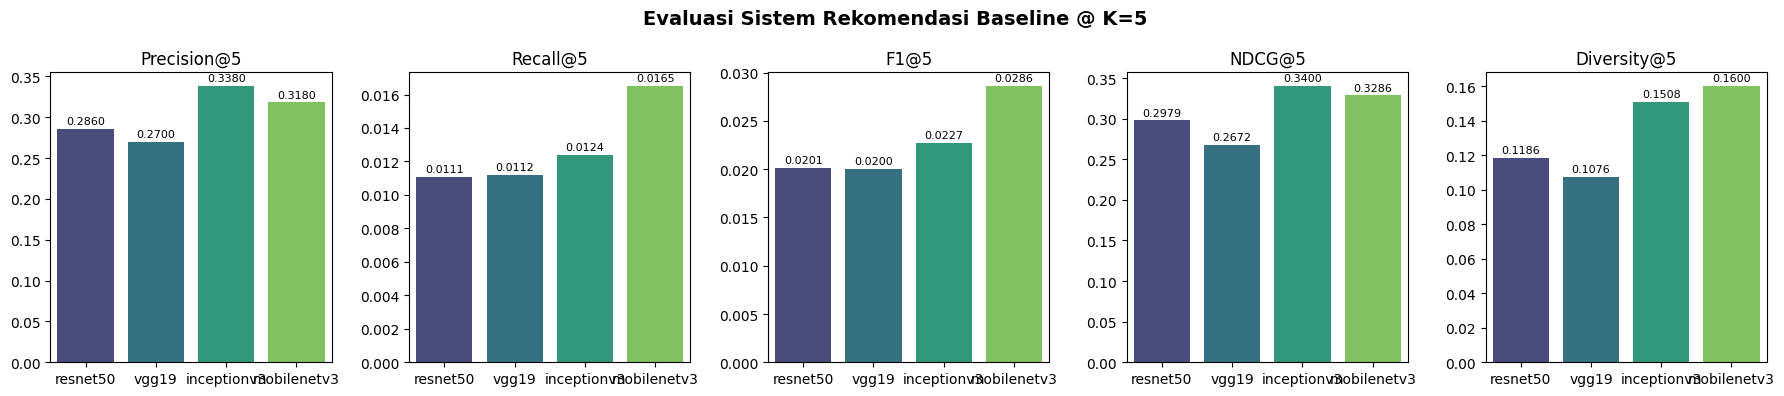

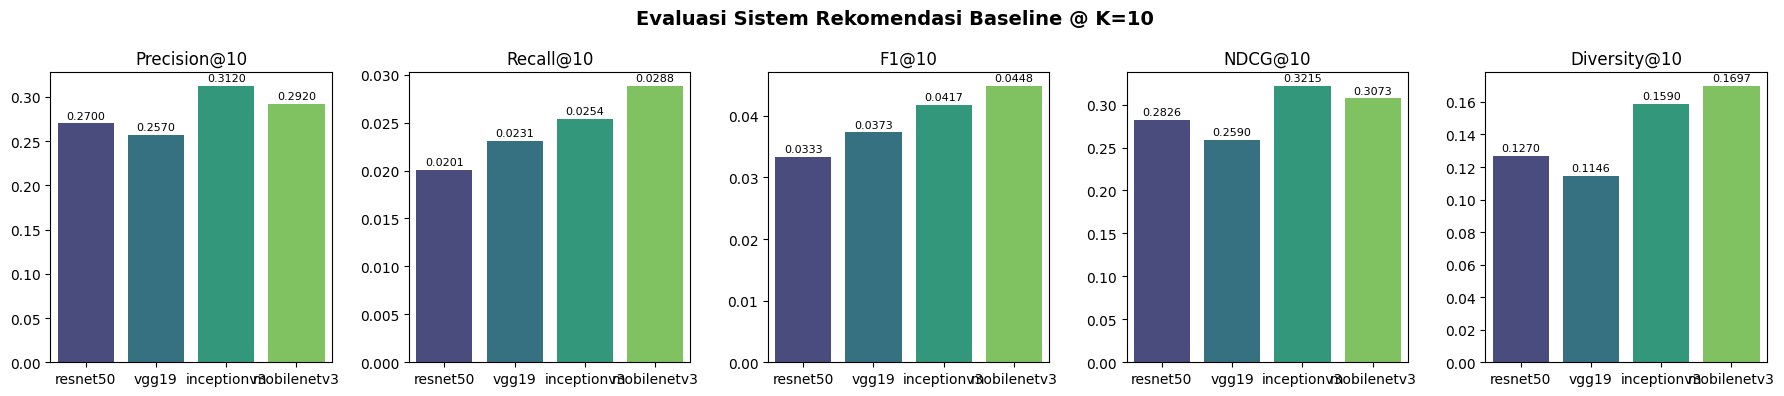

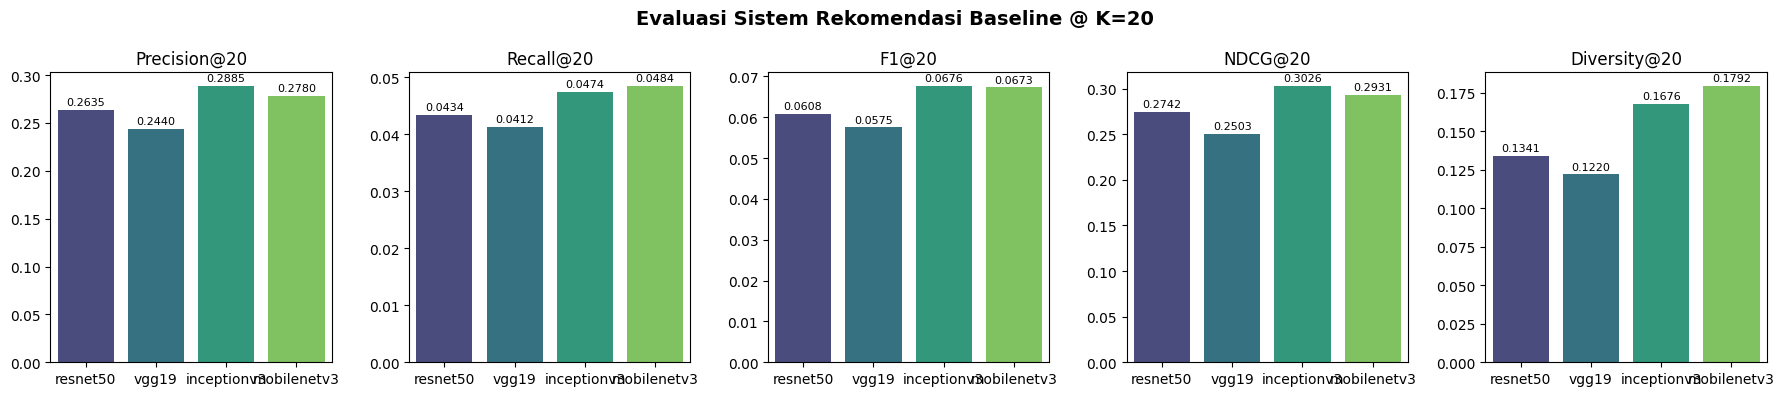

In [7]:
# ─────────────────────────────────────────────
# CELL 7: Tabel Hasil Evaluasi & Grafik Visualisasi
# ─────────────────────────────────────────────
rows = []
for model_name, result in all_results.items():
    for k, metrics in result.items():
        rows.append({
            'Model': model_name,
            'K': k,
            'Precision': round(metrics['precision'], 4),
            'Recall': round(metrics['recall'], 4),
            'F1': round(metrics['f1'], 4),
            'NDCG': round(metrics['ndcg'], 4),
            'Diversity': round(metrics['diversity'], 4)
        })

df_results = pd.DataFrame(rows)
print('\n===========================================================================')
print('  TABEL HASIL EVALUASI REKOMENDER SISTEM - BASELINE')
print('===========================================================================')
print(df_results.to_string(index=False))
print('===========================================================================')

# Simpan ke CSV Hasil
csv_out = os.path.join(EVAL_DIR, 'recommender_evaluation_baseline.csv')
df_results.to_csv(csv_out, index=False)
print(f'\nHasil evaluasi tersimpan di:\n  {csv_out}')

# Visualisasi Bar Chart per Metrik @ K
metrics_list = ['Precision', 'Recall', 'F1', 'NDCG', 'Diversity']
for k in K_VALUES:
    df_k = df_results[df_results['K'] == k]
    fig, axes = plt.subplots(1, len(metrics_list), figsize=(18, 4))
    fig.suptitle(f'Evaluasi Sistem Rekomendasi Baseline @ K={k}', fontsize=14, fontweight='bold')

    for ax, metric in zip(axes, metrics_list):
        sns.barplot(data=df_k, x='Model', y=metric, ax=ax, palette='viridis')
        ax.set_title(f'{metric}@{k}')
        ax.set_xlabel('')
        ax.set_ylabel('')
        for p in ax.patches:
            height = p.get_height()
            ax.annotate(f'{height:.4f}', (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=8, xytext=(0, 2), textcoords='offset points')

    plt.tight_layout()
    plt.show()